K-Means Clustering

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs

# Simulate 300 viral samples. We will secretly make 3 hidden "strains" (centers=3)
# Feature 1: GC Content (%), Feature 2: CpG Frequency
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.5, random_state=42)

# Put it into a Pandas DataFrame for easy viewing
df = pd.DataFrame(X, columns=['GC_Content', 'CpG_Frequency'])

print("Outbreak data generated!")
display(df.head())

Outbreak data generated!


,GC_Content,CpG_Frequency
0,-7.568669,-8.154876
1,-8.170247,-7.456943
2,-1.275380,7.183021
3,4.313357,3.621335
4,-9.936814,-8.392239


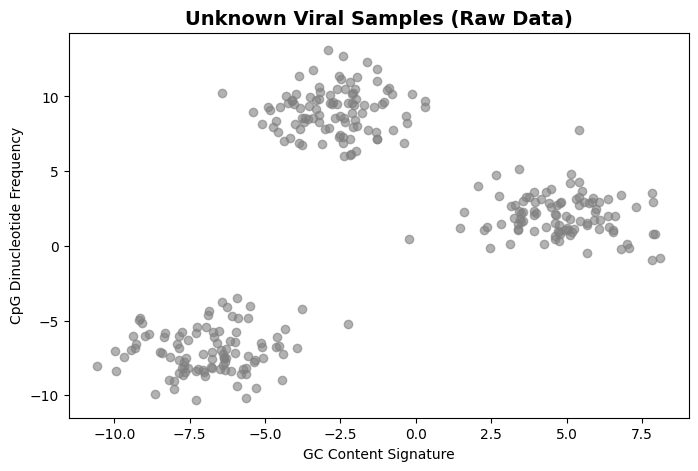

In [10]:
# Plot the raw, unclassified viral samples
plt.figure(figsize=(8, 5))
plt.scatter(df['GC_Content'], df['CpG_Frequency'], color='gray', alpha=0.6)
plt.title("Unknown Viral Samples (Raw Data)", fontsize=14, fontweight='bold')
plt.xlabel("GC Content Signature")
plt.ylabel("CpG Dinucleotide Frequency")
plt.show()

In [11]:
from sklearn.cluster import KMeans

# 1. Initialize the K-Means algorithm, asking it to find 3 strains
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. Fit the model and predict the labels in one step!
# The AI analyzes the data and assigns a group number (0, 1, or 2) to every virus
predicted_strains = kmeans.fit_predict(df)

# 3. Add the AI's discoveries back into our Pandas table
df['Predicted_Strain'] = predicted_strains

print("Machine Learning complete. Hidden strains identified.")

Machine Learning complete. Hidden strains identified.


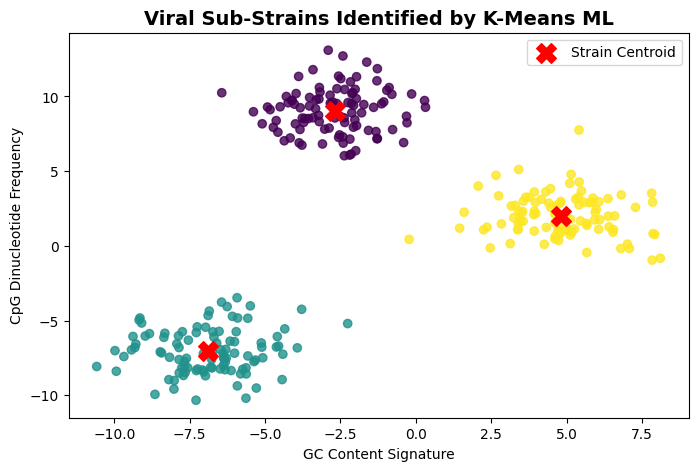

In [12]:
# Plot the Clustered Data
plt.figure(figsize=(8, 5))

# Scatter plot color-coded by the AI's predictions
scatter = plt.scatter(df['GC_Content'], df['CpG_Frequency'], 
                      c=df['Predicted_Strain'], cmap='viridis', alpha=0.8)

# Get the coordinates for the centers of each strain
centroids = kmeans.cluster_centers_

# Plot the Centroids as big red 'X's
plt.scatter(centroids[:, 0], centroids[:, 1], 
            color='red', marker='X', s=200, label='Strain Centroid')

plt.title("Viral Sub-Strains Identified by K-Means ML", fontsize=14, fontweight='bold')
plt.xlabel("GC Content Signature")
plt.ylabel("CpG Dinucleotide Frequency")
plt.legend()
plt.show()